# GANs para Geração de Imagens
**Alunos**: Diogo G. Bonofre dos Santos, Arthur de Paula Zimmermann

## Introdução
Generative Adversarial Network ou simplesmente GAN é um framework para ensinar modelos de deep learning à identificarem padrões em distribuições de dados afim de gerar novos dados a partir das mesmas distribuições.

A GAN consiste de dois modelos, um gerador (*generator*) e um discriminador (*discriminator*). O trabalho do gerador é criar imagens que se pareçam com as imagens de treino, enquanto o do discriminador é olhar as imagens e definir se aquela é uma imagem de treino real ou uma imagem falsa gerada por sua contraparte.

O equilíbrio perfeito buscado dentro desse sistema é fazer com que o gerador crie dados perfeitos que se pareçam com o dataset de treinamento, enquanto o discriminador atinge um limite de certeza de 50% em suas inferências.

## Definindo as Notações Utilizadas

### Para o gerador
- $z$: É um vetor amostrado a partir de uma distribuição de probabilidade simples e conhecida (geralmente uma Gaussiana padrão).
- $G(z)$: É uma rede neural que atua como uma função de transformação de variáveis. Ela recebe o ruído $z$ e o mapeia de forma determinística e não-linear para o espaço complexo de dados (uma matriz com as dimensões da imagem).
- $p_{data}$ e $p_g$: $p_{data}$ representa a distribuição de probabilidade real (e desconhecida) que produziu dataset de treinamento. Já $p_g$ é a distribuição estimada que o gerador $G$ cria. O objetivo final do modelo é fazer com que a divergência entre $p_g$ e $p_{data}$ seja próxima de zero.
- $D(G(z))$: Sabendo que $D(x)$ é a probabilidade do dado $x$ ser real, $D(G(z))$ representa a probabilidade que o discriminador atribui à imagem falsa criada pelo gerador.

### Para o discriminador
- $x$: O dado de entrada, representando aqui a imagem.
- $D(x)$: A rede discriminadora, gerando a probabilidade de $x$ vir do dataset de treino e não do modelo gerador.

> Obs.: Já que estamos lidando com geração de imagens especificamente, aqui assumimos que o input para $D(x)$ seja uma imagem em padrão CHW com dimensões 3x64x64.

$D(x)$ irá resultar em um escalar alto quando $x$ vier do dataset de treino e um escalar baixo quando $x$ for uma imagem artificial. Podemos pensar sobre $D(x)$ como um classificador binário.



## Função de Perda (Minimax)
A premissa do artigo de Goodfellow é formular o treinamento como um jogo de soma zero com dois jogadores, expresso na seguinte função de valor $V(D, G)$:

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_{z}}[\log(1 - D(G(z)))]$$

### Função do Discriminador ($D$)
Seu papel é **maximizar** essa equação. Para atingir o máximo, ele que as previsões para imagens reais, $D(x)$, cheguem perto de 1, e que as previsões para imagens falsas, $D(G(z))$, cheguem perto de 0.


### Função do Gerador ($G$)
Ele só tem influência na segunda metade da equação e seu objetivo é **minimizar** o valor total. Ele tem que enganar o discriminador, assim forçando $D(G(z))$ a se aproximar de 1.
1. Se o gerador for péssimo, o discriminador reconhece a imagem falsa e diz que a probabilidade dela ser real é $0$. A conta fica $\log(1 - 0) = \log(1) = 0$.
2. Se o gerador for perfeito, o discriminador é enganado e diz que a probabilidade da imagem ser real é $100\%$ ($1.0$). A conta fica $\log(1 - 1) = \log(0) \to -\infty$.

## Demonstração da Arquitetura
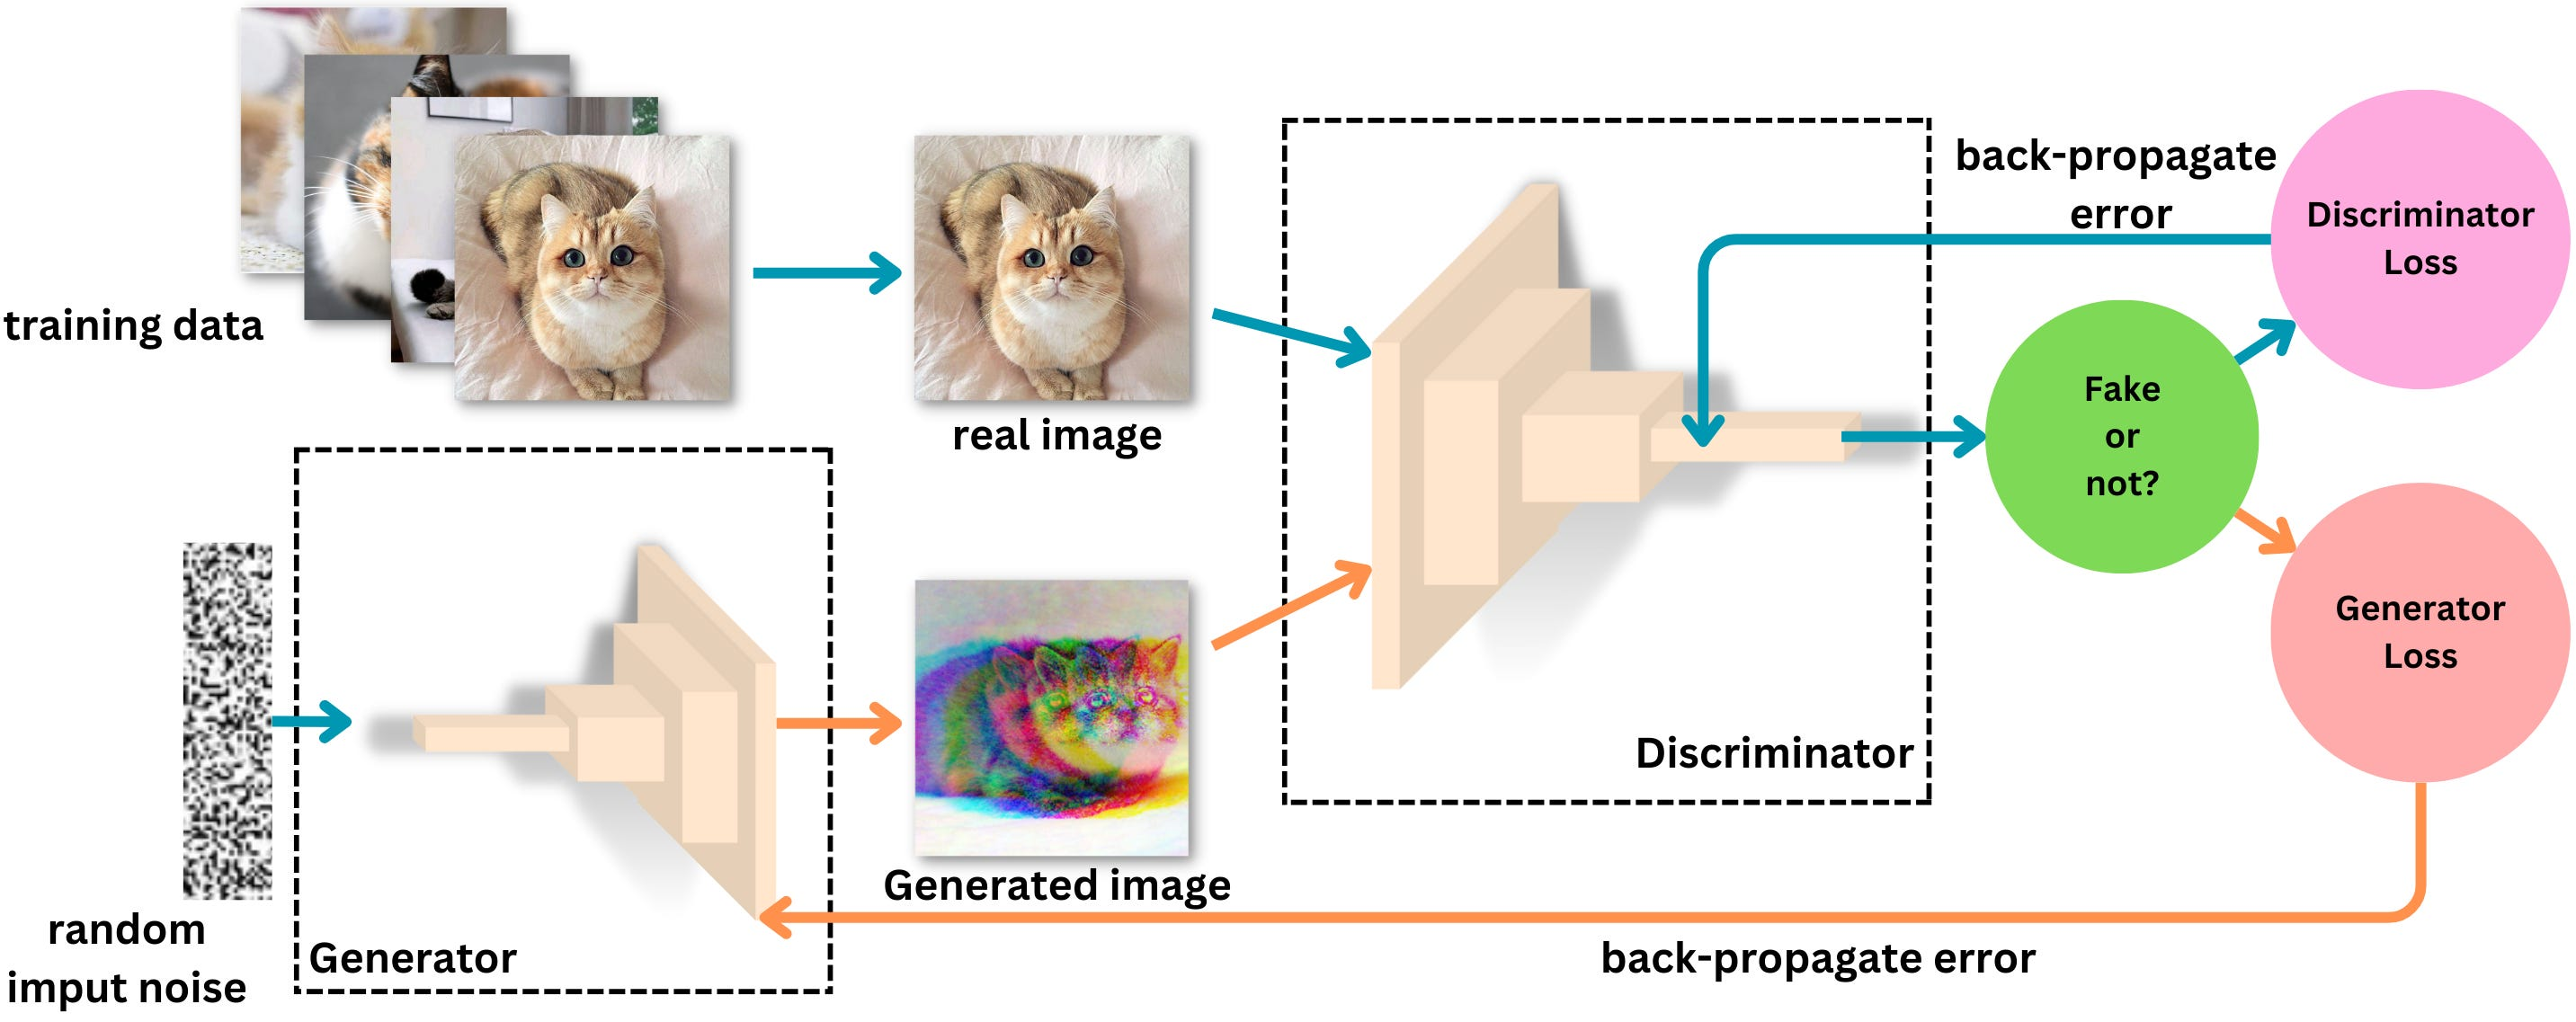

Figura 1: Diagrama de arquitetura da rede demonstrando dados de treino reais ($x$) e imagens artificiais criadas pelo gerador ($G$) sendo processadas pelo discriminador ($D$). Se $D$ erra, retropropaga-se perca deste, se $D$ acerta, retropropagamos perca para $G$.

Fonte: Benveniste, D. (2023a, March 23). How Generative Adversarial Networks work! The AiEdge Newsletter. https://newsletter.theaiedge.io/p/how-generative-adversarial-networks

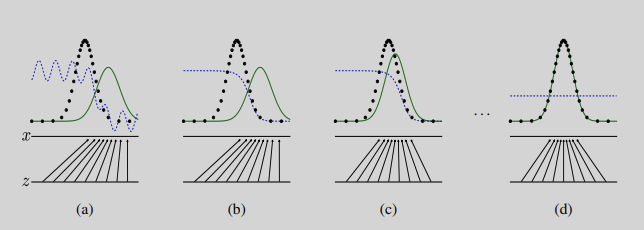

Figura 2: Demonstração do processo de convergência dos modelos. Após muitas iterações, $G$ e $D$ atingirão um estado onde nenhum dos dois pode aprimorar seus resultados pois $p_g=p_{data}$. O discriminador é incapaz de diferenciar entre as duas distribuções, teremos $D(x)=\frac{1}{2}$.

Fonte: Goodfellow (2014, p. 3).

# Implementação GAN com MLPs


## Preparando os dados

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as utils

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cuda


Vamos normalizar os dados convertendo as imagens originais do nosso dataset MNIST (pixels entre 0 e 255) em tensores matemáticos com valores contínuos entre $0.0$ e $0.1$.

Porque a última camada do nosso gerador usará a função `Tahn`, precisamos que as imagens reais também estejam no intervalo de $[-1, 1]$, portanto aplicaremos a função `transforms.Normalize(mean, std)`.

Ela funciona da seguinte maneira:
$$x_{new}=\frac{x_{old}-\text{mean}}{std}$$

Sabendo-se que `transform.ToTensor()` já mapeou nossas entradas ($x_{old}$) para o intervalo $0.0$ a $1.0$, utilizaremos o valor $0.5$ para nossa média e desvio padrão pois então teremos:

- Mínimo: $\frac{(0.0 - 0.5)}{0.5}=-1.0$
- Máximo: $\frac{(1.0 - 0.5)}{0.5}=1.0$

In [2]:
x = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=0.5, std=0.5)
    ])
)

Aqui "embaralhamos" as imagens e dividimos em lotes (*batches*) de 128 amostras por vez.

In [3]:
x_data_loader = torch.utils.data.DataLoader(
    x,
    batch_size=128,
    shuffle=True
)

## Construindo as Redes Neurais

### Discriminador ($D$)
Entendendo as características do modelo:
- Utilizamos 3 camadas densas afim de ajudar o modelo a aprender representações cada vez mais abstratas do input.

- Aplicamos LeakyReLU ao invés de ReLU nas camadas discretas para previnir nossa rede contra *vanishing gradient*. O ReLU padrão tem como saída 0 para qualquer input negativo, o que pode levar a "morte" de alguns neurônios que param de aprender.

- Por fim, aplicamos a função de ativação Sigmoid na última camada do modelo pois visamos uma probabilidade como output, o que torna o intervalo de 0 a 1 dessa função especialmente útil.

In [4]:
class D(nn.Module):
    def __init__(self):
        super().__init__()
        self.nn = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, 784)
        return self.nn(x_flat)

### Gerador ($G$)

In [5]:
class G(nn.Module):
    def __init__(self):
        super().__init__()
        self.nn = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        x_g_flat = self.nn(z)
        # Usar -1 no .view() do PyTorch faz com que ele calcule o tamanho do
        # batch automaticamente com base no que sobrou dos dados.
        # Evita problemas caso o último lote seja menor do que o normal.
        return x_g_flat.view(-1, 1, 28, 28)

### Comparando funções de ativação
$$ReLU = f(x) = \max(0, x)$$
$$LeakyReLU = f(x) = \max(\alpha x, x)$$

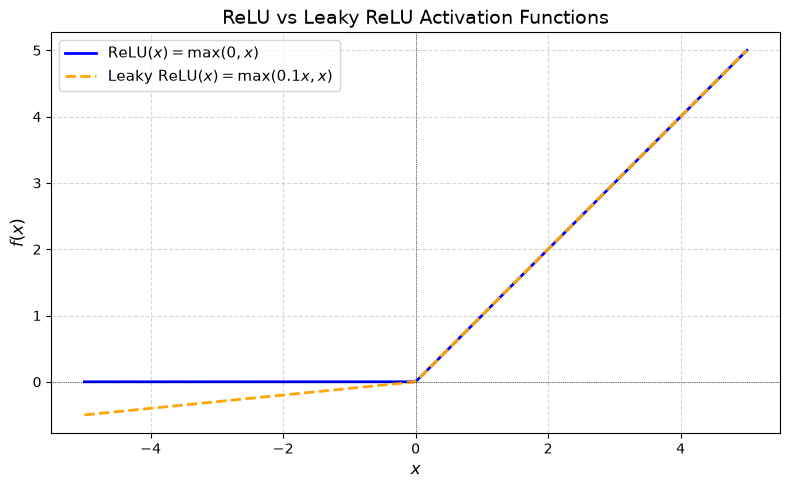

In [6]:
def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

x = np.linspace(-5, 5, 200)
y_relu = relu(x)
y_leaky = leaky_relu(x)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, y_relu, label=r'$\mathrm{ReLU}(x) = \max(0, x)$', color='blue', linewidth=2)
ax.plot(x, y_leaky, label=r'$\mathrm{Leaky\ ReLU}(x) = \max(0.1x, x)$', color='orange', linestyle='--', linewidth=2)

ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.axvline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_title('ReLU vs Leaky ReLU Activation Functions', fontsize=14)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$f(x)$', fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('./images/relu_leaky_relu.png', dpi=300)

In [7]:
d = D().to(device)
g = G().to(device)

loss_function = nn.BCELoss()

optimizer_d = optim.Adam(d.parameters(), lr=0.0002)
optimizer_g = optim.Adam(g.pa rameters(), lr=0.0002)

In [9]:
epochs = 50
fixed_noise = torch.randn((9, 100)).to(device)

epoch_iterator = tqdm(range(epochs), desc="Training GAN", unit="epoch")

for epoch in epoch_iterator:
    # Discard original labels from MNIST with _
    for x_batch, _ in x_data_loader:
        x_batch_size = x_batch.size(0)

        # Move the batch to GPU
        x_batch = x_batch.to(device)

        x_labels = torch.ones((x_batch_size, 1)).to(device)
        z_labels = torch.zeros((x_batch_size, 1)).to(device)
        z = torch.randn((x_batch_size, 100)).to(device)

        # Training the discriminator
        d.train()
        optimizer_d.zero_grad()

        # Passing real images to D
        x_predictions = d(x_batch)
        x_loss = loss_function(x_predictions, x_labels)

        # Passing fake images to D (isolating the G gradient)
        z_predictions = d(g(z).detach())
        z_loss = loss_function(z_predictions, z_labels)

        # Updating D weights
        total_loss = x_loss + z_loss
        total_loss.backward()
        optimizer_d.step()

        # Training the generator
        g.train()
        optimizer_g.zero_grad()

        # Passing fake images (without discarding the G gradient)
        # Evaluating the error against the real image labels 
        z_predictions = d(g(z))
        g_loss = loss_function(z_predictions, x_labels)

        # Updating the weights
        g_loss.backward()
        optimizer_g.step()

    epoch_iterator.set_postfix({"D_Loss": f"{total_loss.item():.4f}", "G_Loss": f"{g_loss.item():.4f}"})

    if (epoch + 1) % 10 == 0:
        g.eval()
        with torch.no_grad():
            g_images = g(fixed_noise)
            g_images =(g_images + 1.0) / 2.0
            file_path = f"./images/gan_epoch_progress_{epoch+1}.png"
            utils.save_image(g_images, file_path, nrow=3)
            tqdm.write(f"Image progress grid saved in: {file_path}")

Training GAN:  20%|██████████████████████████████▌                                                                                                                          | 10/50 [01:15<05:01,  7.54s/epoch, D_Loss=0.2402, G_Loss=6.2983]

Image progress grid saved in: ./images/gan_epoch_progress_10.png


Training GAN:  40%|█████████████████████████████████████████████████████████████▏                                                                                           | 20/50 [02:30<03:44,  7.47s/epoch, D_Loss=0.3090, G_Loss=3.4298]

Image progress grid saved in: ./images/gan_epoch_progress_20.png


Training GAN:  60%|███████████████████████████████████████████████████████████████████████████████████████████▊                                                             | 30/50 [03:46<02:32,  7.65s/epoch, D_Loss=0.3361, G_Loss=4.2192]

Image progress grid saved in: ./images/gan_epoch_progress_30.png


Training GAN:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                              | 40/50 [05:01<01:14,  7.44s/epoch, D_Loss=0.3232, G_Loss=3.2485]

Image progress grid saved in: ./images/gan_epoch_progress_40.png


Training GAN: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [06:15<00:00,  7.51s/epoch, D_Loss=0.4574, G_Loss=3.0488]

Image progress grid saved in: ./images/gan_epoch_progress_50.png


# DCGAN




### Resumo breve
A DCGAN foi proposta em 2015 um ano apos a criacao da GAN de ian goodfellow, procurando unir
o conceito das gans com as redes convolucionais procurando maior precisao na criacao de 
imagens.



### Diferencas 
A GAN Clássica funciona como um modelo inicial baseado em camadas lineares simples. Ela enxerga as imagens de forma "achatada", como se fossem apenas uma longa linha de números, o que limita sua eficácia a datasets muito pequenos como o mnist,e por nao ter um  controle interno ou  padronização de funções, o treinamento é conhecido por ser instável, oscilando  e quebrando facilmente antes de conseguir gerar resultados nítidos.

![Animação de Convolução 2D](https://upload.wikimedia.org/wikipedia/commons/thumb/1/19/2D_Convolution_Animation.gif/250px-2D_Convolution_Animation.gif)

Já a DCGAN visa resolver essa instabilidade trocando as camadas lineares por filtros convolucionais, permitindo que a rede enxergue as imagens em duas dimensões e aprenda formas, curvas e texturas de forma natural. Em vez de esticar os pixels, ela usa convoluções inteligentes que aprendem sozinhas a ampliar e reduzir o tamanho das imagens, com a estabilidade vindo da aplicação de batch normalization que padroniza os dados no meio do caminho para o treino não desandar e no uso de regras fixas para as funções de ativação fazendo o modelo aprender de forma contínua e consiga gerar imagens mais complexas em geral.

### Codigo MNIST DCGAN



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import os


In [ ]:
#hiperparametros

batch_size = 512  
channels = 1      
image_size = 64   
z_dim = 100
features_d = 64
features_g = 64
learning_rate = 0.0002
beta1 = 0.5
epochs = 25  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando na GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


In [ ]:
#dataset

dataset = dset.MNIST(root="./data", download=True,
                     transform=transforms.Compose([
                         transforms.Resize(image_size),
                         transforms.ToTensor(),
                         # para 1 canal
                         transforms.Normalize((0.5,), (0.5,)),
                     ]))


dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"--> Dataset carregado com {len(dataset)} imagens prontas para treino!")


In [ ]:
#arquitetura de um canal
 
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(channels, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(z_dim, features_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

netG = Generator().to(device)
netD = Discriminator().to(device)


In [ ]:
#configuracao de loss e otimizadores 
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=learning_rate, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=learning_rate, betas=(beta1, 0.999))



In [ ]:
#treinamento e preparamento
fixed_noise = torch.randn(9, z_dim, 1, 1, device=device) # ver os mesmos numeros durante  evolucao

# pra nao misturar as coisas na pasta
os.makedirs("resultados_mnist", exist_ok=True)

print("\nIniciando o Treinamento da DCGAN no MNIST...")

for epoch in range(epochs):
    loop = tqdm(enumerate(dataloader), total=len(dataloader), leave=False)
    for i, data in loop:
        
        real_img = data[0].to(device)
        b_size = real_img.size(0)
        
        real_label = torch.ones((b_size,), dtype=torch.float, device=device)
        fake_label = torch.zeros((b_size,), dtype=torch.float, device=device)

        # treina discriminador
        netD.zero_grad()
        output_real = netD(real_img).view(-1)
        loss_D_real = criterion(output_real, real_label)
        loss_D_real.backward()
        
        noise = torch.randn(b_size, z_dim, 1, 1, device=device)
        fake_img = netG(noise)
        
        output_fake = netD(fake_img.detach()).view(-1)
        loss_D_fake = criterion(output_fake, fake_label)
        loss_D_fake.backward()
        optimizerD.step()

        # treina o gerador
        netG.zero_grad()
        output = netD(fake_img).view(-1)
        loss_G = criterion(output, real_label)
        loss_G.backward()
        optimizerG.step()
        
        # isso e pra atualizar as epocas no terminal
        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(loss_D=(loss_D_real + loss_D_fake).item(), loss_G=loss_G.item())

In [ ]:
#salvar tudo

    netG.eval()
    with torch.no_grad():
        fake_images = netG(fixed_noise).detach().cpu()
    netG.train()

    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title(f"Dígitos Falsos (MNIST) - Época {epoch+1}")
    
    # normalize= true pros cinzas ficarem bons
    grid_img = vutils.make_grid(fake_images, nrow=3, padding=2, normalize=True).permute(1,2,0)
    plt.imshow(grid_img, cmap='gray')

    # salva dentro da pasta
    caminho_arquivo = os.path.join("resultados_mnist", f"mnist_epoca_{epoch+1}.png")
    plt.savefig(caminho_arquivo, bbox_inches='tight')
    plt.close() # <---- pra memoria ram
print("\n--> Treinamento concluído com sucesso!")
print("--> Verifique a pasta 'resultados_mnist' na barra lateral do VS Code para ver a evolução.")

# salva peso treinado pra gerar futuramente
torch.save(netG.state_dict(), "gerador_mnist.pth")
print("--> O modelo treinado foi salvo como 'gerador_mnist.pth'.")

# Bibliografia

## Generative Adversarial Networks (GAN)

GOODFELLOW, Ian et al.  
**Generative Adversarial Nets**.  
Advances in Neural Information Processing Systems (NeurIPS), 2014.  
Disponível em: https://arxiv.org/abs/1406.2661

```bibtex
@article{goodfellow2014gan,
  title={Generative Adversarial Nets},
  author={Goodfellow, Ian and Pouget-Abadie, Jean and Mirza, Mehdi and Xu, Bing and Warde-Farley, David and Ozair, Sherjil and Courville, Aaron and Bengio, Yoshua},
  journal={Advances in Neural Information Processing Systems},
  year={2014}
}
````

---

## DCGAN

RADFORD, Alec; METZ, Luke; CHINTALA, Soumith.
**Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks**.
International Conference on Learning Representations (ICLR), 2016.
Disponível em: [https://arxiv.org/abs/1511.06434](https://arxiv.org/abs/1511.06434)

```bibtex
@article{radford2015dcgan,
  title={Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks},
  author={Radford, Alec and Metz, Luke and Chintala, Soumith},
  journal={International Conference on Learning Representations},
  year={2016}
}
```

---

# Referências Complementares
- [DCGAN Tutorial - PyTorch Tutorials](https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html)
- [Understanding GANs (Generative Adversarial Networks) - DeepBean](https://youtu.be/RAa55G-oEuk?si=FzRc1H6g0JNOQ-qf)
- [Making Anime Faces with StyleGAN - Gwern](https://gwern.net/face)
- [Generative Adversarial Networks - Dive Into Deep Learning](https://d2l.ai/chapter_generative-adversarial-networks/gan.html#id2)
- [Ian Goodfellow: Generative Adversarial Networks (GANs) | Lex Fridman Podcast #19
](https://youtu.be/Z6rxFNMGdn0?si=p3WFbrop9XbnYeZK)
